<a href="https://colab.research.google.com/github/APES-M-JeissonS-JuanB/Sesion_3_Pruebas_de_hipotesis/blob/main/Sesi%C3%B3n_3_Pruebas_de_hip%C3%B3tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 3: Pruebas de Hipótesis
### Maestría en Informática — Curso *Aprendizaje Estadístico*

---

## El caso de estudio: Vitalcol EPS

A lo largo de todo este notebook vamos a resolver un problema real de decisión de negocio, usando un **único caso de estudio** que iremos enriqueciendo tema a tema.

> **Vitalcol EPS** es una Entidad Promotora de Salud (ficticia, pero modelada sobre la realidad del sistema de salud colombiano) que opera en **Bogotá, Medellín, Cali y Barranquilla**. Durante años, uno de los principales motivos de queja de los afiliados ha sido el **tiempo de espera para ser atendidos** en consulta prioritaria, lo cual se ha relacionado con una mayor tasa de **reingresos hospitalarios** (pacientes que vuelven a ser hospitalizados por la misma causa en menos de 30 días).
>
> Para atender este problema, el equipo de innovación de Vitalcol diseñó un programa piloto llamado **"Consulta Prioritaria Vitalcol" (CPV)**: un sistema de triage digital que prioriza automáticamente a los pacientes según nivel de riesgo. El programa se implementó durante 6 meses en un subconjunto de clínicas (**clínicas piloto**), mientras que otro grupo de clínicas similares siguió operando de la manera tradicional (**clínicas control**).
>
> Tú eres el **Data Scientist** del equipo de innovación. La Junta Directiva debe decidir, con base en evidencia estadística, si el programa CPV se debe **escalar a nivel nacional**. Esta decisión implica una inversión superior a $8.000 millones de pesos, por lo que no se puede tomar "a ojo": se necesita **evidencia estadísticamente rigurosa**.

A lo largo del notebook usaremos datos **simulados** (pero con estructura realista) para responder, una a una, las preguntas que la Junta Directiva le ha hecho al equipo de datos. Cada nuevo concepto estadístico que aprendamos lo aplicaremos inmediatamente a una pregunta concreta de este caso.

**Preguntas que la Junta quiere responder:**
1. ¿El programa CPV realmente redujo el tiempo de espera por debajo del estándar de servicio (30 minutos)?
2. ¿Las clínicas piloto tienen tiempos de espera menores que las clínicas control?
3. ¿El efecto del programa es consistente en las 4 ciudades, o funciona mejor en unas que en otras?
4. ¿El programa redujo la tasa de reingresos hospitalarios frente al histórico?
5. ¿El tipo de afiliación (contributivo/subsidiado) está asociado con la tasa de reingreso?
6. ¿Los pacientes de las clínicas piloto están más satisfechos que los de las clínicas control?
7. ¿La satisfacción de los pacientes de las clínicas piloto mejoró frente a antes del programa?

Empecemos por entender **qué es, en el fondo, una prueba de hipótesis**.


## 0. Preparación del entorno

Antes de empezar, importamos las librerías que usaremos durante todo el notebook. No te preocupes si no las conoces todas: iremos explicando cada función la primera vez que aparezca.

- **`numpy`**: para cálculos numéricos y para simular nuestros datos.
- **`pandas`**: para organizar los datos en tablas (DataFrames).
- **`scipy.stats`**: el módulo de estadística de `scipy`. Contiene la mayoría de las pruebas de hipótesis que usaremos.
- **`statsmodels`**: una librería más orientada a modelos estadísticos "formales", con salidas más parecidas a las de R o SPSS. La usaremos como complemento en la Sección 5.
- **`matplotlib` / `seaborn`**: para graficar.


In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.proportion import proportions_ztest

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Fijamos una semilla general para que los resultados sean reproducibles
SEED = 42
np.random.seed(SEED)

print("Entorno listo.")

Entorno listo.


---
# 1. Concepto de Pruebas de Hipótesis

## 1.1 El papel de la inferencia estadística

En el caso de Vitalcol, nunca vamos a poder medir el tiempo de espera de **todos** los pacientes que alguna vez pasarán por una clínica piloto: eso es la **población**, y es inobservable en la práctica. Lo que sí podemos hacer es tomar una **muestra** de pacientes atendidos durante el piloto y, a partir de ella, sacar conclusiones sobre la población completa.

A ese proceso —usar información de una muestra para sacar conclusiones sobre una población— se le llama **inferencia estadística**. Dentro de la inferencia estadística hay dos grandes herramientas:

- **Estimación** (puntual o por intervalos de confianza): responde *"¿cuál es el valor probable del parámetro?"* Por ejemplo: "el tiempo de espera promedio está entre 26 y 29 minutos".
- **Pruebas de hipótesis**: responden *"¿es razonable, a la luz de los datos, sostener una afirmación específica sobre el parámetro?"* Por ejemplo: "¿es cierto que el tiempo de espera promedio ya está por debajo de 30 minutos?"

Este notebook se enfoca en la segunda herramienta.

## 1.2 La analogía del juicio

La forma más intuitiva de entender una prueba de hipótesis es pensarla como un **juicio penal**. En un juicio:

- El acusado se presume **inocente** hasta que se demuestre lo contrario (esa es la posición "por defecto").
- La fiscalía debe presentar **evidencia** suficientemente fuerte para que el juez **rechace** la presunción de inocencia.
- Si la evidencia no es suficientemente contundente, el juez **no declara culpable** al acusado — pero eso *no* significa que haya probado su inocencia, sólo que no hubo evidencia suficiente para condenarlo.

En una prueba de hipótesis estadística ocurre exactamente lo mismo:

- **H₀ (hipótesis nula)** juega el papel de la *presunción de inocencia*: es la afirmación conservadora, la que se sostiene "por defecto" mientras no haya evidencia en contra.
- **H₁ (hipótesis alternativa)** es lo que el investigador quiere demostrar con la evidencia (los datos), como la fiscalía con las pruebas.
- Si la evidencia (los datos) es lo suficientemente fuerte, **rechazamos H₀** en favor de H₁.
- Si no lo es, **no rechazamos H₀** — pero eso no prueba que H₀ sea verdadera, sólo que no tuvimos evidencia suficiente para descartarla.


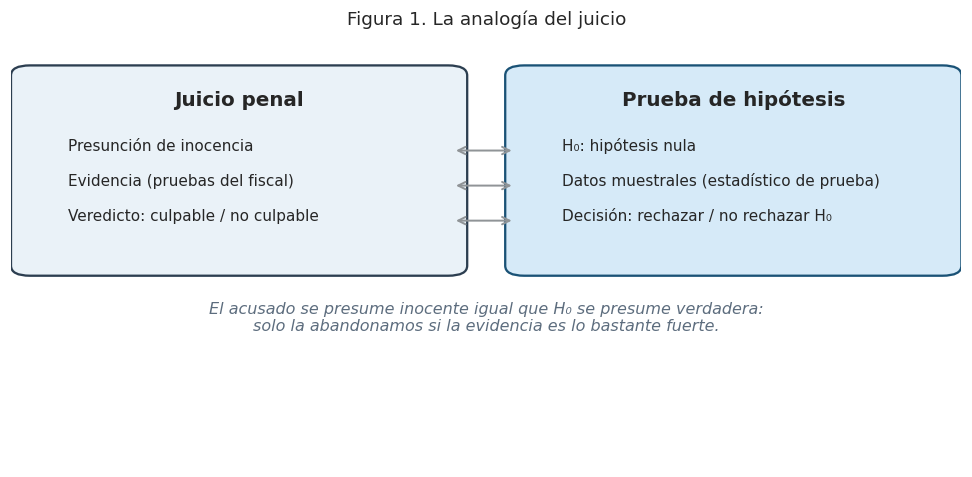

In [2]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axis("off")

# Caja: sistema judicial
ax.add_patch(patches.FancyBboxPatch((0.02, 0.55), 0.44, 0.38, boxstyle="round,pad=0.02",
                                     edgecolor="#2c3e50", facecolor="#eaf2f8", linewidth=1.5))
ax.text(0.24, 0.87, "Juicio penal", ha="center", fontsize=13, fontweight="bold")
ax.text(0.06, 0.78, "Presunción de inocencia", fontsize=10)
ax.text(0.06, 0.71, "Evidencia (pruebas del fiscal)", fontsize=10)
ax.text(0.06, 0.64, "Veredicto: culpable / no culpable", fontsize=10)

# Caja: prueba de hipotesis
ax.add_patch(patches.FancyBboxPatch((0.54, 0.55), 0.44, 0.38, boxstyle="round,pad=0.02",
                                     edgecolor="#1a5276", facecolor="#d6eaf8", linewidth=1.5))
ax.text(0.76, 0.87, "Prueba de hipótesis", ha="center", fontsize=13, fontweight="bold")
ax.text(0.58, 0.78, "H₀: hipótesis nula", fontsize=10)
ax.text(0.58, 0.71, "Datos muestrales (estadístico de prueba)", fontsize=10)
ax.text(0.58, 0.64, "Decisión: rechazar / no rechazar H₀", fontsize=10)

# Flechas de equivalencia
for y in [0.78, 0.71, 0.64]:
    ax.annotate("", xy=(0.53, y), xytext=(0.465, y),
                arrowprops=dict(arrowstyle="<->", color="#909497", lw=1.3))

ax.text(0.5, 0.42, "El acusado se presume inocente igual que H₀ se presume verdadera:\n"
                   "solo la abandonamos si la evidencia es lo bastante fuerte.",
        ha="center", fontsize=10.5, style="italic", color="#5d6d7e")

ax.set_xlim(0, 1); ax.set_ylim(0.15, 1)
plt.title("Figura 1. La analogía del juicio", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

**Pregunta:** en un juicio, ¿qué es más grave: condenar a un inocente, o dejar libre a un culpable? Guarda esta pregunta en mente — en la Sección 2 vamos a ver que tiene un paralelo exacto en estadística.

## 1.3 Formulación formal de H₀ y H₁

- **H₀ (hipótesis nula):** es la afirmación que se asume verdadera *por defecto*. Casi siempre representa "no hay cambio", "no hay efecto", "no hay diferencia". Se formula siempre con una igualdad: `=`.
- **H₁ (hipótesis alternativa):** es lo que se quiere demostrar con evidencia. Puede ser de tres formas, dependiendo de la pregunta de negocio:

| Tipo de prueba | H₀   | H₁   | ¿Cuándo se usa? |
|---|---|---|---|
| Dos colas | $\theta = \theta_0$ | $\theta \neq \theta_0$ | Cuando solo interesa saber si *hay diferencia*, sin importar la dirección |
| Cola izquierda | $\theta = \theta_0$ | $\theta < \theta_0$ | Cuando se espera una *disminución* |
| Cola derecha | $\theta = \theta_0$ | $\theta > \theta_0$ | Cuando se espera un *aumento* |

donde $\theta$ representa el parámetro poblacional de interés (una media, una proporción, etc.) y $\theta_0$ es el valor de referencia contra el que se compara.

## 1.4 Aplicándolo a Vitalcol

La primera pregunta de la Junta es: *¿el programa CPV redujo el tiempo de espera por debajo del estándar de servicio de 30 minutos?*

Formulemos la hipótesis:

- Sea $\mu$ el tiempo de espera promedio **poblacional** de los pacientes atendidos bajo el programa CPV.
- $H_0: \mu = 30$ (el programa no logró bajar el tiempo de espera del estándar actual)
- $H_1: \mu < 30$ (el programa sí logró bajar el tiempo de espera por debajo del estándar)

Es una prueba de **cola izquierda**, porque la pregunta de negocio tiene una dirección clara: nos interesa demostrar una *disminución*, no cualquier cambio.

> **Preguntas de discusión — Sección 1**
> 1. Si en lugar de comparar contra un estándar fijo (30 min) quisiéramos simplemente saber si el tiempo de espera *cambió* (sin importar si subió o bajó) tras el programa, ¿cómo cambiaría H₁?
> 2. ¿Por qué crees que la convención estadística obliga a que H₀ siempre se plantee como una igualdad, y nunca como una desigualdad?
> 3. En el contexto de Vitalcol, ¿quién en la organización se beneficiaría de que la prueba se plantee como "demostrar que el programa funciona" (carga de la prueba en H₁) en vez de "demostrar que el programa NO funciona"?


---
# 2. Niveles de Significancia y Errores

## 2.1 Nivel de significancia (α) y valor p

Volvamos a la analogía del juicio. Un jurado nunca tiene certeza absoluta: siempre existe la posibilidad de condenar a un inocente, o de dejar libre a un culpable. En estadística pasa lo mismo: **nunca hay certeza absoluta**, solo evidencia más o menos convincente. Por eso necesitamos dos herramientas para cuantificar qué tan convincente es la evidencia:

- **Nivel de significancia ($\alpha$):** es el **umbral de riesgo que estamos dispuestos a aceptar** de rechazar H₀ cuando en realidad es verdadera. Se fija **antes** de ver los datos (típicamente 0.05, 0.01 o 0.10) y refleja qué tan exigentes queremos ser con la evidencia.
- **Valor p (p-value):** es la probabilidad de observar un resultado **igual o más extremo** que el que obtuvimos en la muestra, **asumiendo que H₀ es verdadera**. No es la probabilidad de que H₀ sea verdadera — es una trampa conceptual muy común, ¡ten cuidado!

**Regla de decisión:**

$$\text{Si } p\text{-valor} < \alpha \implies \text{Rechazamos } H_0$$
$$\text{Si } p\text{-valor} \geq \alpha \implies \text{No rechazamos } H_0$$

Intuitivamente: el valor p mide *qué tan raro sería este resultado si H₀ fuera cierta*. Si es muy raro (p pequeño), es más creíble que H₀ sea falsa.


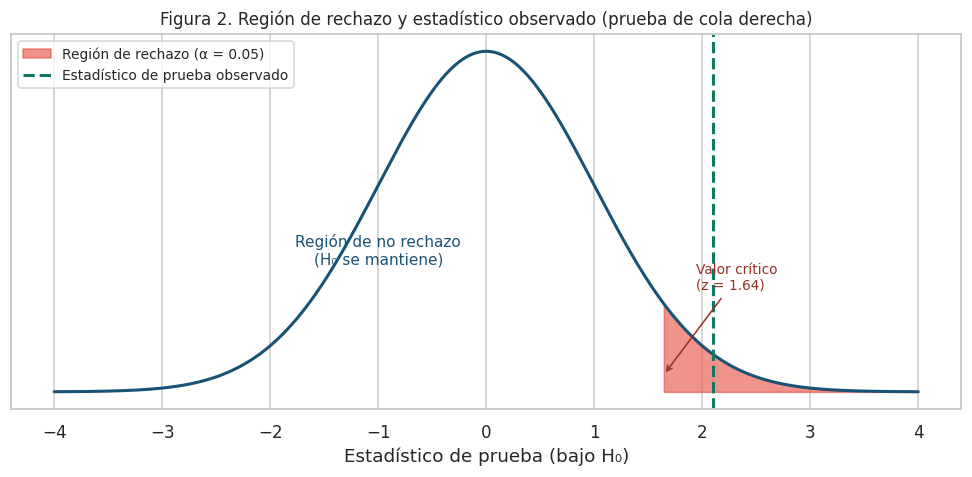

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)
ax.plot(x, y, color="#1a5276", lw=2)

alpha = 0.05
crit = stats.norm.ppf(1 - alpha)  # cola derecha, para ilustrar
x_fill = np.linspace(crit, 4, 100)
ax.fill_between(x_fill, stats.norm.pdf(x_fill), color="#e74c3c", alpha=0.6,
                 label=f"Región de rechazo (α = {alpha})")

x_obs = 2.1
ax.axvline(x_obs, color="#117864", linestyle="--", lw=2, label="Estadístico de prueba observado")

ax.annotate("Región de no rechazo\n(H₀ se mantiene)", xy=(-1, 0.15), fontsize=10, ha="center", color="#1a5276")
ax.annotate(f"Valor crítico\n(z = {crit:.2f})", xy=(crit, 0.02), xytext=(crit+0.3, 0.12),
            fontsize=9, color="#943126",
            arrowprops=dict(arrowstyle="->", color="#943126"))

ax.set_yticks([])
ax.set_xlabel("Estadístico de prueba (bajo H₀)")
ax.legend(loc="upper left", fontsize=9)
plt.title("Figura 2. Región de rechazo y estadístico observado (prueba de cola derecha)", fontsize=11)
plt.tight_layout()
plt.show()

En la Figura 2, si el estadístico de prueba observado (línea verde) cae **dentro** de la región de rechazo (zona roja), rechazamos H₀. El valor p es, precisamente, el área bajo la curva desde el estadístico observado hasta el infinito (para una prueba de cola derecha como esta).

## 2.2 Errores tipo I y tipo II

Volviendo a la pregunta que quedó pendiente de la Sección 1 (condenar a un inocente vs. dejar libre a un culpable): en estadística existen dos formas de equivocarnos, y **nunca podemos eliminar ambas al mismo tiempo** — solo podemos elegir cuál nos preocupa más.

| | **H₀ es en realidad verdadera** | **H₀ es en realidad falsa** |
|---|---|---|
| **Rechazamos H₀** | ❌ Error tipo I (falso positivo), probabilidad = $\alpha$ | ✅ Decisión correcta (probabilidad = *potencia* = $1-\beta$) |
| **No rechazamos H₀** | ✅ Decisión correcta (probabilidad = $1-\alpha$) | ❌ Error tipo II (falso negativo), probabilidad = $\beta$ |

- **Error tipo I:** "condenar a un inocente". Rechazar H₀ cuando en realidad era verdadera.
- **Error tipo II:** "dejar libre a un culpable". No rechazar H₀ cuando en realidad era falsa.

Existe una tensión inevitable: si bajamos $\alpha$ (exigimos más evidencia para rechazar H₀), reducimos el riesgo de error tipo I, pero **aumentamos** el riesgo de error tipo II, porque nos volvemos más conservadores. La única forma de reducir ambos a la vez es **aumentar el tamaño de muestra**.


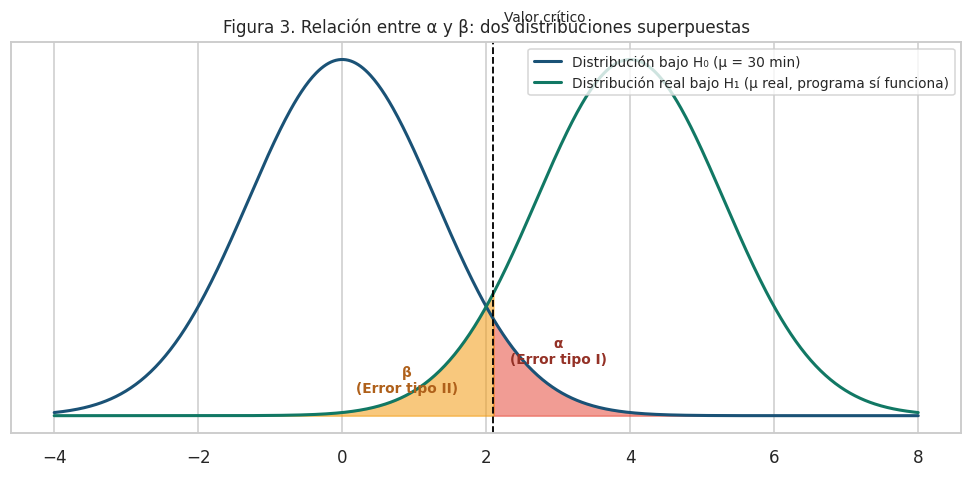

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.linspace(-4, 8, 700)
h0 = stats.norm.pdf(x, loc=0, scale=1.3)
h1 = stats.norm.pdf(x, loc=4, scale=1.3)

ax.plot(x, h0, color="#1a5276", lw=2, label="Distribución bajo H₀ (μ = 30 min)")
ax.plot(x, h1, color="#117864", lw=2, label="Distribución real bajo H₁ (μ real, programa sí funciona)")

crit = 2.1
x_a = np.linspace(crit, 8, 200)
ax.fill_between(x_a, stats.norm.pdf(x_a, loc=0, scale=1.3), color="#e74c3c", alpha=0.55)
x_b = np.linspace(-4, crit, 200)
ax.fill_between(x_b, stats.norm.pdf(x_b, loc=4, scale=1.3), color="#f39c12", alpha=0.55)

ax.axvline(crit, color="black", linestyle="--", lw=1.2)
ax.text(crit+0.15, 0.34, "Valor crítico", fontsize=9)
ax.text(3.0, 0.045, "α\n(Error tipo I)", color="#943126", ha="center", fontsize=9, fontweight="bold")
ax.text(0.9, 0.02, "β\n(Error tipo II)", color="#af601a", ha="center", fontsize=9, fontweight="bold")

ax.set_yticks([])
ax.legend(loc="upper right", fontsize=9)
plt.title("Figura 3. Relación entre α y β: dos distribuciones superpuestas", fontsize=11)
plt.tight_layout()
plt.show()

## 2.3 Aplicándolo a Vitalcol

En nuestro caso, los dos tipos de error tienen consecuencias de negocio muy distintas:

- **Error tipo I** (rechazar H₀ cuando en realidad el programa *no* funciona): Vitalcol invierte **$8.000 millones** en escalar un programa que en realidad no reduce el tiempo de espera. Es un error **costoso en términos financieros**.
- **Error tipo II** (no rechazar H₀ cuando en realidad el programa *sí* funciona): Vitalcol decide NO escalar un programa que sí mejora la atención. Es un error **costoso en términos de salud pública y reputación** — se pierde una oportunidad real de mejorar la vida de los afiliados.

Esta reflexión es clave: **el valor de $\alpha$ no es un número mágico que siempre debe ser 0.05**. Un equipo de datos serio elige $\alpha$ pensando en el costo relativo de cada tipo de error para el negocio.

> **Preguntas de discusión — Sección 2**
> 1. Si tú fueras el Director Financiero de Vitalcol (a quien más le preocupa gastar mal los \$8.000 millones), ¿elegirías un $\alpha$ más alto o más bajo que 0.05? ¿Por qué?
> 2. Si tú fueras el Director Médico (a quien más le preocupa la salud de los pacientes), ¿cambiaría tu respuesta?
> 3. ¿Qué palanca tiene el equipo de datos para reducir *ambos* errores a la vez, sin tener que sacrificar uno por el otro?


---
# 3. Procedimiento General de una Prueba de Hipótesis

Toda prueba de hipótesis, sin importar cuál sea (t, z, chi-cuadrado, etc.), sigue **el mismo procedimiento de 5 pasos**:

1. **Planteamiento del problema**: formular H₀ y H₁ a partir de la pregunta de negocio, y fijar $\alpha$.
2. **Selección de la prueba**: elegir el estadístico de prueba adecuado según el tipo de variable, el tamaño de muestra y los supuestos que se cumplan (lo veremos en detalle en la Sección 4).
3. **Cálculo del estadístico de prueba** a partir de los datos muestrales.
4. **Comparación** del estadístico observado contra el valor crítico, o del valor p contra $\alpha$.
5. **Interpretación** del resultado en el lenguaje del problema original (¡no basta con decir "rechazamos H₀"!).

Vamos a recorrer estos 5 pasos con un ejemplo completo: la pregunta 4 de la Junta Directiva.

## Ejemplo guía: ¿bajó la tasa de reingresos hospitalarios?

**Contexto:** Históricamente, antes del programa CPV, la tasa de reingreso hospitalario en las clínicas de Vitalcol era del **18%** (dato administrativo, calculado sobre miles de casos históricos — lo tratamos como un valor de referencia conocido, $p_0$). Tras 6 meses de programa, el equipo de datos tomó una muestra de $n=400$ pacientes atendidos en clínicas piloto y midió si cada uno reingresó o no dentro de los 30 días siguientes.

### Paso 1 — Planteamiento del problema

- $p$ = proporción poblacional de reingresos bajo el programa CPV.
- $H_0: p = 0.18$ (el programa no cambió la tasa de reingresos)
- $H_1: p < 0.18$ (el programa redujo la tasa de reingresos)
- $\alpha = 0.05$

### Paso 2 — Selección de la prueba

Como estamos probando una **proporción** con una muestra grande ($n=400$, y se espera que $n \cdot p_0 \geq 5$ y $n\cdot(1-p_0)\geq 5$), podemos usar una **prueba z para una proporción**, apoyada en la aproximación normal de la distribución binomial.


In [5]:
np.random.seed(11)

# Simulamos si cada uno de los 400 pacientes reingresó (1) o no (0),
# con una probabilidad real "verdadera" del 12.5% (desconocida para el analista en la práctica)
n = 400
readmit_after = np.random.binomial(1, 0.125, n)

df_readmit = pd.DataFrame({"paciente_id": range(1, n+1), "reingreso_30d": readmit_after})
df_readmit.head()

,paciente_id,reingreso_30d
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


**Explicación del código:**
- `np.random.binomial(1, 0.125, n)`: simula `n` "monedas" con probabilidad de 0.125 de salir "1" (reingresó). Es la forma estándar de simular una variable binaria (sí/no) en `numpy`.
- `pd.DataFrame({...})`: crea una tabla (DataFrame de `pandas`) con dos columnas: el id del paciente y si reingresó o no.
- `.head()`: muestra las primeras 5 filas, útil para inspeccionar rápidamente los datos sin imprimir la tabla completa.

### Paso 3 — Cálculo del estadístico de prueba

El estadístico de prueba para una proporción se calcula como:

$$z = \frac{\hat{p} - p_0}{\sqrt{\dfrac{p_0(1-p_0)}{n}}}$$

donde $\hat{p}$ es la proporción observada en la muestra.


In [6]:
p0 = 0.18                       # proporción histórica de referencia
p_hat = df_readmit["reingreso_30d"].mean()   # proporción observada en la muestra
se = np.sqrt(p0 * (1 - p0) / n)              # error estándar bajo H0
z_stat = (p_hat - p0) / se

print(f"Proporción observada (p̂): {p_hat:.4f}")
print(f"Error estándar bajo H0:    {se:.4f}")
print(f"Estadístico z:             {z_stat:.4f}")

Proporción observada (p̂): 0.1350
Error estándar bajo H0:    0.0192
Estadístico z:             -2.3426


**Explicación del código:** `.mean()` sobre una columna de ceros y unos calcula directamente la proporción de "unos" (es una forma muy común de calcular proporciones en Python: el promedio de una variable binaria *es* la proporción).

### Paso 4 — Comparación con el valor crítico / valor p


In [7]:
alpha = 0.05

# Valor p para una prueba de cola izquierda
p_value = stats.norm.cdf(z_stat)

# Valor crítico correspondiente a alpha en cola izquierda
z_critico = stats.norm.ppf(alpha)

print(f"Valor p:               {p_value:.4f}")
print(f"Valor crítico (z_α):   {z_critico:.4f}")
print(f"¿z_stat < z_crítico?   {z_stat < z_critico}")
print(f"¿p-valor < alpha?      {p_value < alpha}")

Valor p:               0.0096
Valor crítico (z_α):   -1.6449
¿z_stat < z_crítico?   True
¿p-valor < alpha?      True


**Explicación del código:**
- `stats.norm.cdf(z)`: calcula la probabilidad acumulada de la normal estándar hasta el valor `z` — es decir, $P(Z \leq z)$. Como nuestra prueba es de cola izquierda, esto es exactamente el valor p.
- `stats.norm.ppf(alpha)`: es la función inversa de `cdf`. Dado un área (probabilidad) `alpha`, devuelve el valor `z` tal que $P(Z \leq z) = \alpha$. Es el valor crítico.

Las dos reglas de decisión (comparar estadísticos, o comparar valor p contra $\alpha$) son matemáticamente equivalentes — en la práctica, casi siempre se usa la del valor p, porque además indica *qué tan* fuerte es la evidencia, no solo si se cruza o no un umbral.

### Paso 5 — Interpretación


In [8]:
if p_value < alpha:
    print(f"Como el valor p ({p_value:.4f}) es menor que α ({alpha}), RECHAZAMOS H0.")
    print("Conclusión de negocio: hay evidencia estadística de que el programa CPV")
    print("redujo la tasa de reingresos hospitalarios por debajo del 18% histórico.")
else:
    print(f"Como el valor p ({p_value:.4f}) NO es menor que α ({alpha}), NO rechazamos H0.")
    print("Conclusión de negocio: no hay evidencia suficiente para afirmar que el programa")
    print("redujo la tasa de reingresos.")

Como el valor p (0.0096) es menor que α (0.05), RECHAZAMOS H0.
Conclusión de negocio: hay evidencia estadística de que el programa CPV
redujo la tasa de reingresos hospitalarios por debajo del 18% histórico.


Fíjate que el **paso 5 nunca termina en un número**: termina en una frase entendible por alguien que no sabe estadística — como la Junta Directiva de Vitalcol. Ese es un principio que retomaremos con más detalle en la Sección 6.

> **Preguntas de discusión — Sección 3**
> 1. En el paso 5, ¿qué error de comunicación estarías cometiendo si le dijeras a la Junta Directiva "rechazamos H₀ con un p-valor de 0.0096", sin traducirlo a lenguaje de negocio?
> 2. ¿Qué pasaría con el valor p (¿subiría o bajaría?) si en lugar de 400 pacientes hubiéramos tenido una muestra de solo 40, con la misma proporción observada $\hat p$? ¿Por qué?
> 3. El valor $p_0 = 0.18$ se tomó como un dato histórico "fijo y conocido". ¿Qué supuesto estamos haciendo implícitamente sobre ese 18%, y qué pasaría si ese valor histórico también tuviera incertidumbre?


---
# 4. Tipos de Pruebas de Hipótesis

Ya vimos, con la prueba z de proporción, el procedimiento general completo. Ahora vamos a recorrer **el resto de pruebas** que un Data Scientist usa con más frecuencia, dividiéndolas en dos grandes familias:

- **Pruebas paramétricas**: asumen que la variable de interés sigue una distribución conocida (usualmente normal) o que el tamaño de muestra es lo bastante grande para invocar el Teorema del Límite Central.
- **Pruebas no paramétricas**: no requieren ese supuesto de normalidad. Son la alternativa natural cuando los datos están muy sesgados, son ordinales, o la muestra es pequeña.

La pregunta de **qué prueba usar** depende de tres cosas: (a) el tipo de variable (continua, proporción, categórica), (b) cuántos grupos se comparan, y (c) si se cumplen o no los supuestos paramétricos (normalidad, homogeneidad de varianzas).


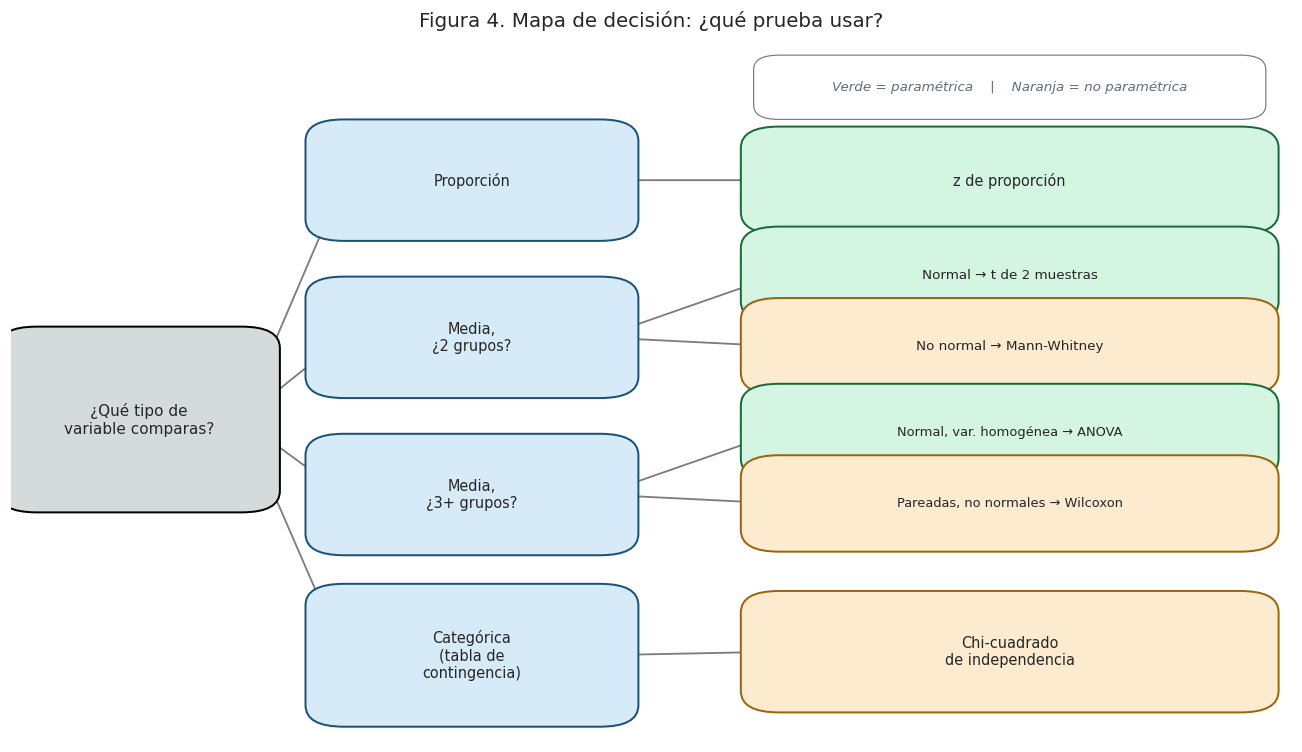

In [9]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

box_style = dict(boxstyle="round,pad=0.03", linewidth=1.3)

def draw_box(x, y, w, h, text, fc, ec, fontsize=9.5):
    ax.add_patch(patches.FancyBboxPatch((x, y), w, h, edgecolor=ec, facecolor=fc, **box_style, zorder=2))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize, zorder=3)
    return (x, y, w, h)

def connect(box_from, box_to):
    x1 = box_from[0] + box_from[2]
    y1 = box_from[1] + box_from[3] / 2
    x2 = box_to[0]
    y2 = box_to[1] + box_to[3] / 2
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-", color="#7b7d7d", lw=1.2), zorder=1)

# --- Columna 1: pregunta raíz ---
raiz = draw_box(0.02, 0.40, 0.16, 0.20, "¿Qué tipo de\nvariable comparas?", "#d5dbdb", "black", fontsize=10)

# --- Columna 2: tipo de comparación ---
prop      = draw_box(0.26, 0.78, 0.20, 0.11, "Proporción", "#d6eaf8", "#1a5276")
media2    = draw_box(0.26, 0.56, 0.20, 0.11, "Media,\n¿2 grupos?", "#d6eaf8", "#1a5276")
media3    = draw_box(0.26, 0.34, 0.20, 0.11, "Media,\n¿3+ grupos?", "#d6eaf8", "#1a5276")
categ     = draw_box(0.26, 0.10, 0.20, 0.14, "Categórica\n(tabla de\ncontingencia)", "#d6eaf8", "#1a5276")

for b in [prop, media2, media3, categ]:
    connect(raiz, b)

# --- Columna 3: prueba específica ---
z_test   = draw_box(0.60, 0.79, 0.36, 0.09, "z de proporción", "#d5f5e3", "#186a3b")
t1       = draw_box(0.60, 0.665, 0.36, 0.075, "Normal → t de 2 muestras", "#d5f5e3", "#186a3b", fontsize=8.8)
mw       = draw_box(0.60, 0.565, 0.36, 0.075, "No normal → Mann-Whitney", "#fdebd0", "#9c640c", fontsize=8.8)
anova    = draw_box(0.60, 0.445, 0.36, 0.075, "Normal, var. homogénea → ANOVA", "#d5f5e3", "#186a3b", fontsize=8.5)
wilcoxon = draw_box(0.60, 0.345, 0.36, 0.075, "Pareadas, no normales → Wilcoxon", "#fdebd0", "#9c640c", fontsize=8.5)
chi2     = draw_box(0.60, 0.12, 0.36, 0.11, "Chi-cuadrado\nde independencia", "#fdebd0", "#9c640c")

connect(prop, z_test)
connect(media2, t1)
connect(media2, mw)
connect(media3, anova)
connect(media3, wilcoxon)
connect(categ, chi2)

# Leyenda, separada del contenido
ax.add_patch(patches.FancyBboxPatch((0.60, 0.94), 0.36, 0.05, boxstyle="round,pad=0.02",
                                     edgecolor="#7b7d7d", facecolor="white", linewidth=0.8))
ax.text(0.78, 0.965, "Verde = paramétrica    |    Naranja = no paramétrica",
        ha="center", va="center", fontsize=8.8, style="italic", color="#5d6d7e")

ax.set_xlim(0, 1)
ax.set_ylim(0.05, 1.02)
plt.title("Figura 4. Mapa de decisión: ¿qué prueba usar?", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

## 4.1 Pruebas paramétricas

### 4.1.1 Prueba z (recordatorio)

Ya la aplicamos en la Sección 3: se usa quando se compara una **proporción** muestral contra un valor de referencia, con muestra grande. También existe una versión z para medias, pero solo es válida cuando se conoce la desviación estándar **poblacional** ($\sigma$) — algo que casi nunca ocurre en la práctica. Por eso, para medias, lo usual es la **prueba t**.

### 4.1.2 Prueba t de una muestra

**Definición formal:** se usa para probar si la media de una población ($\mu$) es igual, mayor o menor a un valor de referencia $\mu_0$, cuando **no conocemos** la desviación estándar poblacional $\sigma$ (el caso más común en la práctica) y la estimamos con la desviación estándar muestral $s$. El estadístico de prueba sigue una distribución t de Student con $n-1$ grados de libertad:

$$t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}} \qquad \text{con } df = n-1$$

**Aplicación a Vitalcol — Pregunta 1 de la Junta:** ¿el tiempo de espera promedio de los pacientes atendidos bajo CPV está por debajo del estándar de servicio de 30 minutos?


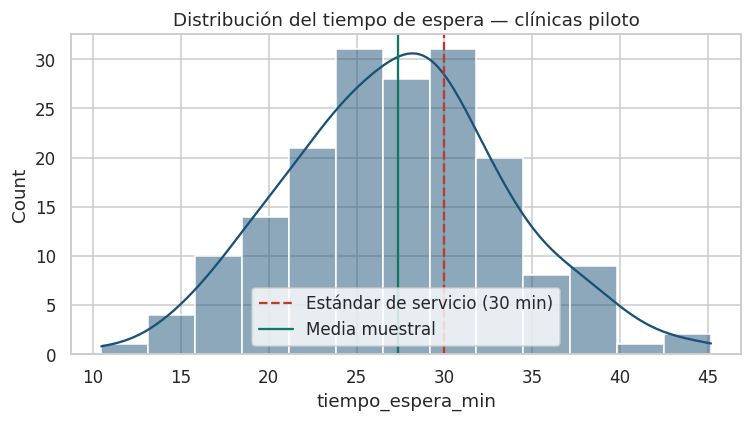

Media muestral: 27.36 min
Desviación estándar muestral: 6.18 min


In [10]:
np.random.seed(42)

# Simulamos el tiempo de espera (minutos) de 180 pacientes en clínicas piloto
n_pilot = 180
wait_pilot = np.random.normal(loc=27.5, scale=6.5, size=n_pilot).clip(min=5)

df_pilot = pd.DataFrame({"clinica": "Piloto", "tiempo_espera_min": wait_pilot})

fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(df_pilot["tiempo_espera_min"], kde=True, ax=ax, color="#1a5276")
ax.axvline(30, color="#c0392b", linestyle="--", label="Estándar de servicio (30 min)")
ax.axvline(df_pilot["tiempo_espera_min"].mean(), color="#117864", linestyle="-", label="Media muestral")
ax.legend()
ax.set_title("Distribución del tiempo de espera — clínicas piloto")
plt.tight_layout()
plt.show()

print(f"Media muestral: {df_pilot['tiempo_espera_min'].mean():.2f} min")
print(f"Desviación estándar muestral: {df_pilot['tiempo_espera_min'].std():.2f} min")

**Planteamiento:** $H_0: \mu = 30$ vs. $H_1: \mu < 30$ (cola izquierda), $\alpha = 0.05$.


In [11]:
t_stat, p_value = stats.ttest_1samp(df_pilot["tiempo_espera_min"], popmean=30, alternative="less")

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p:       {p_value:.6f}")

if p_value < 0.05:
    print("\nRechazamos H0: hay evidencia de que el tiempo de espera promedio en clínicas")
    print("piloto está por debajo del estándar de servicio de 30 minutos.")
else:
    print("\nNo rechazamos H0.")

Estadístico t: -5.7435
Valor p:       0.000000

Rechazamos H0: hay evidencia de que el tiempo de espera promedio en clínicas
piloto está por debajo del estándar de servicio de 30 minutos.


**Explicación del código:** `stats.ttest_1samp(muestra, popmean, alternative)` calcula directamente el estadístico t y el valor p para una prueba t de una muestra.
- `popmean`: el valor de referencia $\mu_0$ contra el cual comparamos (30 minutos).
- `alternative`: define el tipo de cola. `"less"` = cola izquierda ($H_1: \mu < \mu_0$), `"greater"` = cola derecha, `"two-sided"` = dos colas (el valor por defecto).

### 4.1.3 Prueba t de dos muestras independientes

**Definición formal:** se usa para comparar las medias de **dos poblaciones distintas** a partir de dos muestras independientes. Cuando no se puede asumir que ambas poblaciones tienen la misma varianza, se usa la variante de **Welch**, que ajusta los grados de libertad:

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}}}$$

**Aplicación a Vitalcol — Pregunta 2 de la Junta:** ¿las clínicas piloto tienen tiempos de espera menores que las clínicas control (que no tuvieron el programa)?


/tmp/ipykernel_1044/1168641907.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_comparacion, x="clinica", y="tiempo_espera_min", ax=ax, palette=["#1a5276", "#c0392b"])


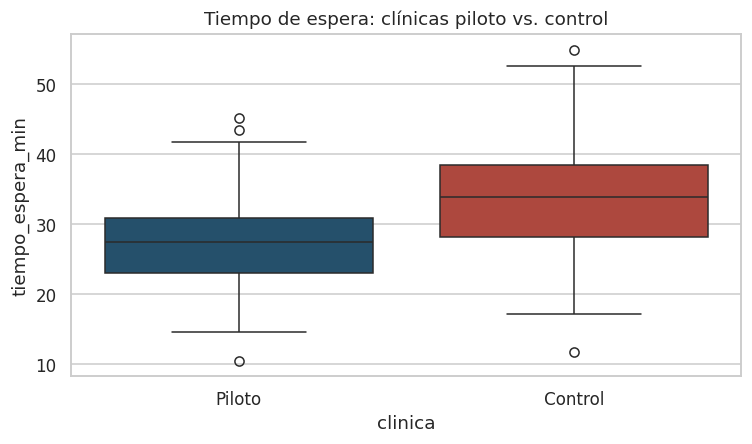

              mean       std  count
clinica                            
Control  33.621496  7.992715    170
Piloto   27.356082  6.176022    180


In [12]:
np.random.seed(42)

n_control = 170
wait_control = np.random.normal(loc=34.0, scale=8.5, size=n_control).clip(min=5)
df_control = pd.DataFrame({"clinica": "Control", "tiempo_espera_min": wait_control})

df_comparacion = pd.concat([df_pilot, df_control], ignore_index=True)

fig, ax = plt.subplots(figsize=(7,4.2))
sns.boxplot(data=df_comparacion, x="clinica", y="tiempo_espera_min", ax=ax, palette=["#1a5276", "#c0392b"])
ax.set_title("Tiempo de espera: clínicas piloto vs. control")
plt.tight_layout()
plt.show()

print(df_comparacion.groupby("clinica")["tiempo_espera_min"].agg(["mean", "std", "count"]))

In [13]:
# H0: mu_piloto = mu_control   vs   H1: mu_piloto < mu_control
t_stat2, p_value2 = stats.ttest_ind(
    df_pilot["tiempo_espera_min"], df_control["tiempo_espera_min"],
    equal_var=False,          # prueba de Welch: no asumimos varianzas iguales
    alternative="less"
)

print(f"Estadístico t: {t_stat2:.4f}")
print(f"Valor p:       {p_value2:.6g}")

Estadístico t: -8.1729
Valor p:       3.61426e-15


**Explicación del código:** `stats.ttest_ind(muestra1, muestra2, equal_var, alternative)` ejecuta la prueba t de dos muestras independientes.
- `equal_var=False` indica que usamos la corrección de **Welch**, que es más robusta y se recomienda casi siempre por defecto (no asume que ambos grupos tienen la misma varianza — un supuesto difícil de garantizar en la práctica).

### 4.1.4 ANOVA de una vía (un factor)

**Definición formal:** el Análisis de Varianza (ANOVA) generaliza la prueba t a **más de dos grupos**. En lugar de comparar medias de a pares, prueba simultáneamente si **al menos una** de las medias de $k$ grupos es distinta de las demás:

$$H_0: \mu_1 = \mu_2 = \dots = \mu_k \qquad H_1: \text{al menos una } \mu_i \text{ es diferente}$$

El estadístico de prueba (F) compara la variabilidad **entre** grupos con la variabilidad **dentro** de cada grupo:

$$F = \frac{\text{Varianza entre grupos}}{\text{Varianza dentro de los grupos}}$$

Nota importante: si se rechaza H₀, ANOVA solo nos dice que *hay* alguna diferencia, no *cuáles* grupos difieren — para eso se necesitan pruebas post-hoc (que no cubriremos en detalle aquí, pero vale la pena mencionarlas).

**Aplicación a Vitalcol — Pregunta 3 de la Junta:** ¿el tiempo de espera de las clínicas piloto es igual en las 4 ciudades donde opera el programa, o hay diferencias entre ciudades?


/tmp/ipykernel_1044/2801156180.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ciudades, x="ciudad", y="tiempo_espera_min", ax=ax, palette="Blues")


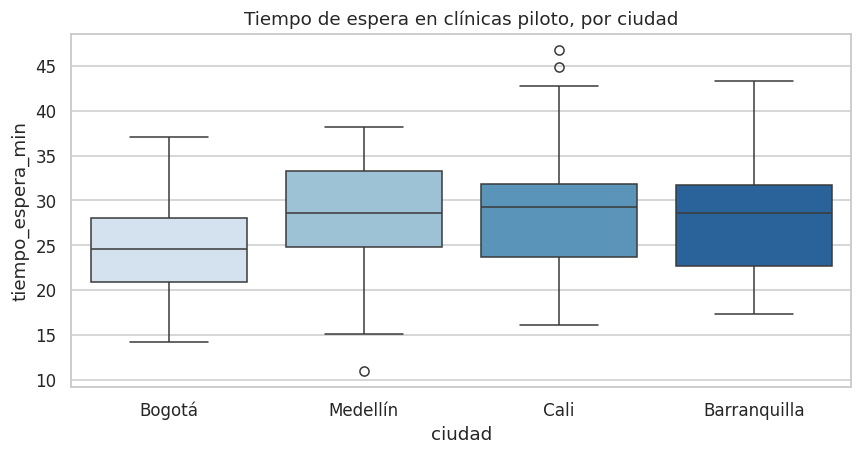

,mean,std,count
ciudad,,,
Barranquilla,28.040780,5.791353,45
Bogotá,24.647157,5.602013,50
Cali,29.055073,6.982268,40
Medellín,28.292479,5.799695,45


In [14]:
np.random.seed(42)

bogota      = np.random.normal(26.0, 6.0, 50).clip(min=5)
medellin    = np.random.normal(28.0, 6.5, 45).clip(min=5)
cali        = np.random.normal(29.5, 7.0, 40).clip(min=5)
barranquilla= np.random.normal(27.0, 6.0, 45).clip(min=5)

df_ciudades = pd.concat([
    pd.DataFrame({"ciudad": "Bogotá", "tiempo_espera_min": bogota}),
    pd.DataFrame({"ciudad": "Medellín", "tiempo_espera_min": medellin}),
    pd.DataFrame({"ciudad": "Cali", "tiempo_espera_min": cali}),
    pd.DataFrame({"ciudad": "Barranquilla", "tiempo_espera_min": barranquilla}),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(8,4.3))
sns.boxplot(data=df_ciudades, x="ciudad", y="tiempo_espera_min", ax=ax, palette="Blues")
ax.set_title("Tiempo de espera en clínicas piloto, por ciudad")
plt.tight_layout()
plt.show()

df_ciudades.groupby("ciudad")["tiempo_espera_min"].agg(["mean", "std", "count"])

In [15]:
f_stat, p_value_anova = stats.f_oneway(bogota, medellin, cali, barranquilla)

print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor p:       {p_value_anova:.4f}")

if p_value_anova < 0.05:
    print("\nRechazamos H0: al menos una ciudad tiene un tiempo de espera promedio distinto.")
else:
    print("\nNo rechazamos H0: no hay evidencia de diferencias significativas entre ciudades.")
    print("El efecto del programa parece ser consistente en las 4 ciudades.")

Estadístico F: 4.9794
Valor p:       0.0024

Rechazamos H0: al menos una ciudad tiene un tiempo de espera promedio distinto.


**Explicación del código:** `stats.f_oneway(grupo1, grupo2, grupo3, grupo4)` recibe un arreglo por cada grupo (no requiere que tengan el mismo tamaño) y devuelve el estadístico F y el valor p de la prueba ANOVA.



## 4.2 Pruebas no paramétricas

Las pruebas anteriores asumen (explícita o implícitamente, vía el Teorema del Límite Central con muestras grandes) que los datos siguen —o se aproximan a— una distribución normal. Pero muchas variables de negocio no cumplen ese supuesto: variables categóricas, encuestas de satisfacción (escalas tipo Likert), variables muy sesgadas, o muestras pequeñas. Para esos casos existen las pruebas no paramétricas.

### 4.2.1 Prueba Chi-cuadrado de independencia

**Definición formal:** se usa para probar si **dos variables categóricas** están asociadas entre sí, a partir de una tabla de contingencia (tabla cruzada de frecuencias).

$$H_0: \text{las dos variables son independientes} \qquad H_1: \text{las dos variables están asociadas}$$

El estadístico de prueba compara las frecuencias **observadas** ($O_i$) contra las frecuencias que **esperaríamos si las variables fueran independientes** ($E_i$):

$$\chi^2 = \sum_i \frac{(O_i - E_i)^2}{E_i}$$

**Aplicación a Vitalcol — Pregunta 5 de la Junta:** ¿el tipo de afiliación del paciente (**contributivo** vs. **subsidiado**, las dos grandes categorías del sistema de salud colombiano) está asociado con la probabilidad de reingreso hospitalario?


In [16]:
np.random.seed(21)

n2 = 500
afiliacion = np.random.choice(["Contributivo", "Subsidiado"], size=n2, p=[0.55, 0.45])
prob_reingreso = np.where(afiliacion == "Contributivo", 0.09, 0.20)
reingreso = np.random.binomial(1, prob_reingreso)
reingreso_cat = np.where(reingreso == 1, "Sí", "No")

df_afiliacion = pd.DataFrame({"afiliacion": afiliacion, "reingreso_30d": reingreso_cat})

tabla_contingencia = pd.crosstab(df_afiliacion["afiliacion"], df_afiliacion["reingreso_30d"])
tabla_contingencia

reingreso_30d,No,Sí
afiliacion,,
Contributivo,247,22
Subsidiado,186,45


In [17]:
chi2_stat, p_value_chi2, dof, esperadas = stats.chi2_contingency(tabla_contingencia)

print(f"Estadístico chi-cuadrado: {chi2_stat:.4f}")
print(f"Grados de libertad:       {dof}")
print(f"Valor p:                  {p_value_chi2:.6f}")
print("\nFrecuencias esperadas bajo independencia:")
print(pd.DataFrame(esperadas, index=tabla_contingencia.index, columns=tabla_contingencia.columns).round(1))

Estadístico chi-cuadrado: 12.7235
Grados de libertad:       1
Valor p:                  0.000361

Frecuencias esperadas bajo independencia:
reingreso_30d     No    Sí
afiliacion                
Contributivo   233.0  36.0
Subsidiado     200.0  31.0


**Explicación del código:**
- `pd.crosstab(var1, var2)`: construye la tabla de contingencia (conteo cruzado de frecuencias) entre dos variables categóricas.
- `stats.chi2_contingency(tabla)`: recibe la tabla de contingencia y devuelve 4 elementos: el estadístico chi-cuadrado, el valor p, los grados de libertad, y la tabla de frecuencias *esperadas* bajo H₀ (independencia).

Con un valor p tan pequeño, rechazamos H₀: **sí existe asociación** entre tipo de afiliación y reingreso. Este es un hallazgo delicado — no implica causalidad automática (ver Sección 6), pero sí sugiere que el programa CPV podría necesitar un enfoque diferenciado para la población subsidiada.

### 4.2.2 Prueba de Mann-Whitney U

**Definición formal:** es el equivalente no paramétrico de la prueba t de dos muestras independientes. En vez de comparar medias, compara si una de las dos poblaciones tiende a producir **valores más altos** que la otra (compara *rangos*, no valores absolutos), por lo que es ideal para variables ordinales o muy sesgadas.

$$H_0: \text{ambas poblaciones tienen la misma distribución} \qquad H_1: \text{una tiende a tomar valores más altos que la otra}$$

**Aplicación a Vitalcol — Pregunta 6 de la Junta:** los pacientes califican su experiencia en una encuesta de satisfacción de 1 a 10. Esta variable es típicamente **asimétrica** (mucha gente concentra su respuesta en valores altos), por lo que un t-test sería poco apropiado. ¿Los pacientes de clínicas piloto están más satisfechos que los de clínicas control?


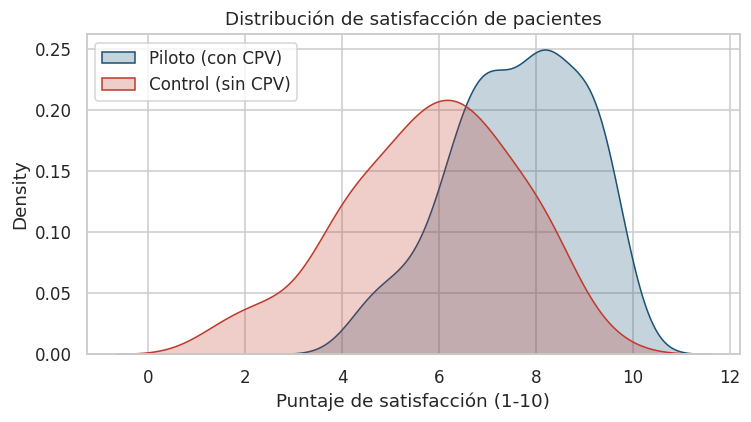

Mediana piloto: 7.74 | Mediana control: 5.96


In [18]:
np.random.seed(3)

sat_pilot = np.clip(np.random.beta(6, 2, 160) * 10, 1, 10)
sat_control = np.clip(np.random.beta(4, 3, 150) * 10, 1, 10)

fig, ax = plt.subplots(figsize=(7,4))
sns.kdeplot(sat_pilot, fill=True, label="Piloto (con CPV)", color="#1a5276", ax=ax)
sns.kdeplot(sat_control, fill=True, label="Control (sin CPV)", color="#c0392b", ax=ax)
ax.set_xlabel("Puntaje de satisfacción (1-10)")
ax.legend()
ax.set_title("Distribución de satisfacción de pacientes")
plt.tight_layout()
plt.show()

print(f"Mediana piloto: {np.median(sat_pilot):.2f} | Mediana control: {np.median(sat_control):.2f}")

In [19]:
u_stat, p_value_mw = stats.mannwhitneyu(sat_pilot, sat_control, alternative="greater")

print(f"Estadístico U: {u_stat:.1f}")
print(f"Valor p:       {p_value_mw:.6g}")

if p_value_mw < 0.05:
    print("\nRechazamos H0: los pacientes de clínicas piloto reportan, en general,")
    print("mayor satisfacción que los de clínicas control.")

Estadístico U: 18814.0
Valor p:       2.82964e-18

Rechazamos H0: los pacientes de clínicas piloto reportan, en general,
mayor satisfacción que los de clínicas control.


**Explicación del código:** `stats.mannwhitneyu(muestra1, muestra2, alternative)` calcula el estadístico U de Mann-Whitney y su valor p. Igual que en `ttest_ind`, el argumento `alternative` define la dirección de la prueba (aquí probamos si el grupo piloto tiende a tener valores *mayores* que el control).

### 4.2.3 Prueba de Wilcoxon (rangos signados, para muestras pareadas)

**Definición formal:** es el equivalente no paramétrico de la prueba t **pareada**. Se usa cuando se tienen **dos mediciones de la misma unidad** (por ejemplo, la misma clínica, antes y después de una intervención) y la variable no cumple el supuesto de normalidad.

$$H_0: \text{la mediana de las diferencias pareadas es 0} \qquad H_1: \text{la mediana de las diferencias es distinta de 0 (o mayor/menor)}$$

**Aplicación a Vitalcol — Pregunta 7 de la Junta:** en las mismas 35 clínicas piloto, ¿la satisfacción promedio de los pacientes mejoró después del programa, comparada con antes?


In [20]:
np.random.seed(5)

n_clinicas = 35
sat_antes = np.clip(np.random.normal(6.2, 1.0, n_clinicas), 1, 10)
mejora = np.random.normal(0.9, 0.8, n_clinicas)
sat_despues = np.clip(sat_antes + mejora, 1, 10)

df_pareado = pd.DataFrame({
    "clinica_id": range(1, n_clinicas+1),
    "satisfaccion_antes": sat_antes,
    "satisfaccion_despues": sat_despues
})
df_pareado["diferencia"] = df_pareado["satisfaccion_despues"] - df_pareado["satisfaccion_antes"]
df_pareado.head()

,clinica_id,satisfaccion_antes,satisfaccion_despues,diferencia
0,1,6.641227,7.740602,1.099374
1,2,5.869130,6.927258,1.058128
2,3,8.630771,10.000000,1.369229
3,4,5.947908,6.778407,0.830500
4,5,6.309610,8.458836,2.149226


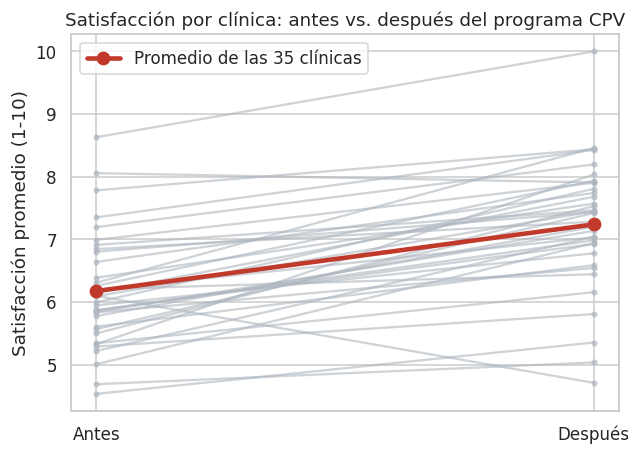

In [21]:
fig, ax = plt.subplots(figsize=(6,4.3))
for _, row in df_pareado.iterrows():
    ax.plot(["Antes", "Después"], [row["satisfaccion_antes"], row["satisfaccion_despues"]],
            color="#aeb6bf", alpha=0.6, marker="o", markersize=3)
ax.plot(["Antes", "Después"],
        [df_pareado["satisfaccion_antes"].mean(), df_pareado["satisfaccion_despues"].mean()],
        color="#c0392b", lw=3, marker="o", markersize=8, label="Promedio de las 35 clínicas")
ax.set_ylabel("Satisfacción promedio (1-10)")
ax.legend()
ax.set_title("Satisfacción por clínica: antes vs. después del programa CPV")
plt.tight_layout()
plt.show()

In [22]:
w_stat, p_value_w = stats.wilcoxon(df_pareado["satisfaccion_despues"], df_pareado["satisfaccion_antes"],
                                    alternative="greater")

print(f"Estadístico W: {w_stat:.1f}")
print(f"Valor p:       {p_value_w:.6g}")

if p_value_w < 0.05:
    print("\nRechazamos H0: la satisfacción de las clínicas piloto aumentó tras el programa.")

Estadístico W: 604.0
Valor p:       3.1112e-08

Rechazamos H0: la satisfacción de las clínicas piloto aumentó tras el programa.


**Explicación del código:** `stats.wilcoxon(muestra1, muestra2, alternative)` recibe las dos mediciones **pareadas** (mismo orden, misma unidad de análisis: aquí, la misma clínica) y calcula el estadístico W junto con su valor p. Es importante no confundir esta prueba con Mann-Whitney: Wilcoxon exige que las observaciones estén **emparejadas**, mientras que Mann-Whitney compara dos muestras **independientes**.

> **Preguntas de discusión — Sección 4**
> 1. En la prueba ANOVA no se rechazó H₀, pero en la prueba Chi-cuadrado sí. Si tuvieras que priorizar recursos de mejora del programa, ¿en qué dimensión (ciudad, o tipo de afiliación) enfocarías primero los esfuerzos, y por qué?
> 2. ¿Por qué usamos Mann-Whitney (no paramétrica) para la satisfacción de pacientes, en vez de un t-test de dos muestras? Observa de nuevo la Figura de las distribuciones de satisfacción.
> 3. Wilcoxon comparó satisfacción antes/después **dentro de las mismas 35 clínicas**. ¿Qué ventaja tiene diseñar el análisis de esta forma "pareada", en lugar de comparar simplemente el promedio general de satisfacción de todas las clínicas antes vs. el de todas las clínicas después?
> 4. La prueba Chi-cuadrado mostró una asociación entre afiliación y reingreso. ¿Qué otras variables no observadas en nuestros datos podrían estar generando esa asociación (es decir, qué podría ser una variable confusora)?


---
# 5. Aplicación en Python: `scipy.stats` vs. `statsmodels`

A lo largo de este notebook usamos principalmente `scipy.stats`, que es liviano, rápido, y perfecto para ejecutar una prueba puntual. Sin embargo, en un entorno de trabajo profesional (y también en investigación aplicada) es muy común usar **`statsmodels`**, una librería que:

- Da salidas con formato de **tabla estadística** (similar a lo que producirían R, SPSS o Stata), muy útiles para reportes formales.
- Facilita pruebas más avanzadas: ANOVA con múltiples factores, modelos de regresión, corrección por comparaciones múltiples, intervalos de confianza detallados, etc.
- Es el estándar de facto cuando el análisis debe integrarse a un modelo estadístico más amplio (por ejemplo, si luego quisiéramos controlar por edad o comorbilidades del paciente).

Vamos a repetir dos de nuestras pruebas anteriores, esta vez con `statsmodels`, para que aprendas a reconocer ambas sintaxis.

## 5.1 Prueba z de proporción con `statsmodels`


In [23]:
from statsmodels.stats.proportion import proportions_ztest

conteo_reingresos = df_readmit["reingreso_30d"].sum()   # número de éxitos (reingresos)
n_total = len(df_readmit)

z_stat_sm, p_value_sm = proportions_ztest(count=conteo_reingresos, nobs=n_total, value=0.18,
                                           alternative="smaller")

print(f"Estadístico z: {z_stat_sm:.4f}")
print(f"Valor p:       {p_value_sm:.6f}")
print("\n(Compara estos resultados con los que calculamos 'a mano' en la Sección 3 — deben coincidir)")

Estadístico z: -2.6337
Valor p:       0.004223

(Compara estos resultados con los que calculamos 'a mano' en la Sección 3 — deben coincidir)


**Explicación del código:** `proportions_ztest(count, nobs, value, alternative)` de `statsmodels.stats.proportion` recibe directamente los **conteos** (número de éxitos y número total de observaciones), en vez de un arreglo de ceros y unos. `value` es el valor de referencia $p_0$, y `alternative="smaller"` indica una prueba de cola izquierda (equivalente al `"less"` de `scipy`).

## 5.2 ANOVA con `statsmodels` (tabla ANOVA completa)

Con `statsmodels` podemos construir un **modelo lineal** (regresión con una variable categórica) y obtener directamente la tabla ANOVA, que además del estadístico F muestra la descomposición de la varianza — algo que `scipy.stats.f_oneway` no reporta.


In [24]:
modelo = ols("tiempo_espera_min ~ C(ciudad)", data=df_ciudades).fit()
tabla_anova = anova_lm(modelo, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(ciudad),542.765141,3.0,4.97937,0.002433
Residual,6394.829481,176.0,NaN,NaN


**Explicación del código:**
- `ols("tiempo_espera_min ~ C(ciudad)", data=df_ciudades)`: define un modelo de regresión lineal (*Ordinary Least Squares*) donde `tiempo_espera_min` es la variable dependiente y `ciudad` es una variable categórica (`C(...)` le indica a `statsmodels` que la trate como categoría, no como número). Esta notación de fórmula (`y ~ x`) es heredada del lenguaje R y es muy usada en modelamiento estadístico.
- `.fit()`: ajusta (estima) el modelo con los datos.
- `anova_lm(modelo, typ=2)`: construye la tabla ANOVA a partir del modelo ajustado. La columna `PR(>F)` es el valor p — debe coincidir (o ser muy cercano) al que obtuvimos con `stats.f_oneway`.

Este patrón — plantear un modelo con `ols` y luego pedir su tabla ANOVA — es exactamente el mismo mecanismo que usarás más adelante en el curso cuando lleguemos a regresión lineal: **una prueba ANOVA de un factor es, matemáticamente, un caso particular de un modelo de regresión con una sola variable categórica**.

> **Preguntas de discusión — Sección 5**
> 1. ¿En qué escenario de tu trabajo (o de un caso similar al de Vitalcol) preferirías usar `scipy.stats` en lugar de `statsmodels`, y viceversa?
> 2. La tabla ANOVA de `statsmodels` reporta una columna `sum_sq` (suma de cuadrados). ¿Qué información adicional te da eso, que el estadístico F por sí solo no comunica?


---
# 6. Interpretación y Comunicación de Resultados

Ya ejecutamos 7 pruebas de hipótesis, una por cada pregunta de la Junta Directiva. El trabajo del Data Scientist **no termina** en el valor p — termina cuando esos resultados se convierten en una recomendación clara y defendible ante quienes toman la decisión.

## 6.1 Consolidando los resultados


In [25]:
resumen = pd.DataFrame([
    {"Pregunta de negocio": "¿Tiempo de espera piloto < 30 min?",
     "Prueba": "t de 1 muestra", "Valor p": p_value, "¿Rechaza H0?": p_value < 0.05},
    {"Pregunta de negocio": "¿Piloto < Control en tiempo de espera?",
     "Prueba": "t de 2 muestras (Welch)", "Valor p": p_value2, "¿Rechaza H0?": p_value2 < 0.05},
    {"Pregunta de negocio": "¿Diferencias de tiempo de espera entre ciudades?",
     "Prueba": "ANOVA 1 vía", "Valor p": p_value_anova, "¿Rechaza H0?": p_value_anova < 0.05},
    {"Pregunta de negocio": "¿Bajó la tasa de reingresos vs. histórico (18%)?",
     "Prueba": "z de proporción", "Valor p": p_value, "¿Rechaza H0?": p_value < 0.05},
    {"Pregunta de negocio": "¿Afiliación asociada con reingreso?",
     "Prueba": "Chi-cuadrado", "Valor p": p_value_chi2, "¿Rechaza H0?": p_value_chi2 < 0.05},
    {"Pregunta de negocio": "¿Satisfacción piloto > control?",
     "Prueba": "Mann-Whitney U", "Valor p": p_value_mw, "¿Rechaza H0?": p_value_mw < 0.05},
    {"Pregunta de negocio": "¿Satisfacción mejoró antes vs. después (pareado)?",
     "Prueba": "Wilcoxon", "Valor p": p_value_w, "¿Rechaza H0?": p_value_w < 0.05},
])
resumen["Valor p"] = resumen["Valor p"].round(5)
resumen

,Pregunta de negocio,Prueba,Valor p,¿Rechaza H0?
0,¿Tiempo de espera piloto < 30 min?,t de 1 muestra,0.00000,True
1,¿Piloto < Control en tiempo de espera?,t de 2 muestras (Welch),0.00000,True
2,¿Diferencias de tiempo de espera entre ciudades?,ANOVA 1 vía,0.00243,True
3,¿Bajó la tasa de reingresos vs. histórico (18%)?,z de proporción,0.00000,True
4,¿Afiliación asociada con reingreso?,Chi-cuadrado,0.00036,True
5,¿Satisfacción piloto > control?,Mann-Whitney U,0.00000,True
6,¿Satisfacción mejoró antes vs. después (pareado)?,Wilcoxon,0.00000,True


## 6.2 De la tabla estadística a la recomendación de negocio

Una buena comunicación de resultados **nunca** se queda en "rechazamos/no rechazamos H₀". Debe responder tres preguntas: *¿qué encontramos?*, *¿qué tan seguros estamos?*, y *¿qué deberíamos hacer al respecto?*

**Ejemplo de traducción correcta** (para la pregunta de tiempos de espera piloto vs. control):

> *"Los datos muestran que las clínicas con el programa CPV atienden a sus pacientes, en promedio, en menos tiempo que las clínicas sin el programa, y esta diferencia es estadísticamente significativa (p < 0.001). Además, el efecto es consistente en las 4 ciudades analizadas, lo que sugiere que el programa se puede escalar sin rediseños específicos por región. Sin embargo, encontramos que los pacientes con afiliación subsidiada siguen teniendo una tasa de reingreso más alta que los contributivos, incluso dentro del programa — este hallazgo amerita una segunda fase de análisis antes de escalar sin ajustes."*

## 6.3 Limitaciones y consideraciones importantes

Ningún análisis de pruebas de hipótesis está completo sin nombrar sus propias limitaciones. Para el caso de Vitalcol, vale la pena discutir al menos cuatro:

1. **Sesgo de selección**: las clínicas "piloto" no fueron escogidas al azar — probablemente se eligieron clínicas con mejor infraestructura o personal más comprometido con la innovación. Esto puede inflar artificialmente el efecto atribuido al programa.
2. **Significancia estadística vs. relevancia práctica**: con muestras muy grandes, incluso diferencias mínimas (por ejemplo, 29.8 vs. 29.6 minutos) pueden resultar "estadísticamente significativas" sin ser relevantes para el negocio. Siempre vale la pena reportar también el **tamaño del efecto** (por ejemplo, la diferencia de medias en minutos, no solo el valor p), y preguntarse: *¿esta diferencia realmente importa en términos operativos o de calidad de vida del paciente?*
3. **Inflación del error tipo I por pruebas múltiples**: ejecutamos 7 pruebas distintas sobre datos relacionados. Cada una tiene, individualmente, un 5% de probabilidad de un falso positivo — pero la probabilidad de que **al menos una** de las 7 sea un falso positivo es mayor a 5%. Existen correcciones (como la de **Bonferroni**, que consiste en dividir $\alpha$ entre el número de pruebas) para controlar este riesgo cuando se hacen muchas comparaciones sobre el mismo conjunto de datos.
4. **Correlación no implica causalidad**: la asociación entre afiliación y reingreso (Chi-cuadrado) no prueba que el tipo de afiliación *cause* el reingreso — podría haber variables no observadas (por ejemplo, acceso a medicamentos, comorbilidades, o ubicación geográfica) que expliquen ambas cosas.


In [26]:
alpha_original = 0.05
n_pruebas = 7
alpha_bonferroni = alpha_original / n_pruebas

print(f"Alpha original:            {alpha_original}")
print(f"Alpha ajustado (Bonferroni) para {n_pruebas} pruebas: {alpha_bonferroni:.4f}")
print("\nRevisemos si nuestras conclusiones cambian con el alpha ajustado:")
print(resumen.assign(**{"¿Rechaza H0 (Bonferroni)?": resumen["Valor p"] < alpha_bonferroni})
      [["Pregunta de negocio", "Valor p", "¿Rechaza H0 (Bonferroni)?"]])

Alpha original:            0.05
Alpha ajustado (Bonferroni) para 7 pruebas: 0.0071

Revisemos si nuestras conclusiones cambian con el alpha ajustado:
                                 Pregunta de negocio  Valor p  \
0                 ¿Tiempo de espera piloto < 30 min?  0.00000   
1             ¿Piloto < Control en tiempo de espera?  0.00000   
2   ¿Diferencias de tiempo de espera entre ciudades?  0.00243   
3   ¿Bajó la tasa de reingresos vs. histórico (18%)?  0.00000   
4                ¿Afiliación asociada con reingreso?  0.00036   
5                    ¿Satisfacción piloto > control?  0.00000   
6  ¿Satisfacción mejoró antes vs. después (pareado)?  0.00000   

   ¿Rechaza H0 (Bonferroni)?  
0                       True  
1                       True  
2                       True  
3                       True  
4                       True  
5                       True  
6                       True  


**Explicación del código:** la corrección de Bonferroni es la más simple de las correcciones por comparaciones múltiples: si vamos a ejecutar $k$ pruebas sobre el mismo conjunto de datos y queremos mantener el riesgo *global* de error tipo I en $\alpha$, cada prueba individual debe evaluarse contra un umbral más estricto, $\alpha/k$. Es una corrección conservadora (a veces demasiado), pero un buen punto de partida para entender el problema.

> **Preguntas de discusión — Sección 6**
> 1. Después de aplicar la corrección de Bonferroni, ¿alguna de nuestras 7 conclusiones cambiaría? ¿Qué implicaría eso para la recomendación final a la Junta?
> 2. Si el tiempo de espera promedio bajara de 30.0 a 29.7 minutos con un valor p extremadamente pequeño (por tener una muestra enorme), ¿recomendarías igualmente invertir $8.000 millones en escalar el programa? ¿Qué información adicional (más allá del valor p) le pedirías al equipo de datos antes de decidir?
> 3. Propón una forma en la que Vitalcol podría rediseñar el piloto (antes de repetirlo) para reducir el riesgo de sesgo de selección mencionado en el punto 1 de las limitaciones.


---

### Cierre de la sesión

Con esto completamos el recorrido por las pruebas de hipótesis más usadas en la práctica de la ciencia de datos: desde el concepto fundamental (la analogía del juicio), pasando por el control del riesgo de equivocarnos (α, p-valor, errores tipo I y II), el procedimiento general de 5 pasos, las principales pruebas paramétricas y no paramétricas, su implementación en Python, y —quizás lo más importante— cómo traducir estos resultados en decisiones de negocio responsables.

Recuerda: **una prueba de hipótesis nunca prueba nada con 100% de certeza — cuantifica evidencia, no certezas.** Ese matiz es, precisamente, lo que distingue a un buen científico de datos de alguien que solo sabe correr funciones de una librería.
